In [52]:
from langgraph.graph import START, END, StateGraph
from typing import TypedDict, Literal
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

In [53]:
class CreateValidateBlog(TypedDict):
    topic: str
    generated_blog: str
    evaluation: Literal["Approved", "Needs_Improvement"]
    feedback: str
    iteration: int
    max_iteration: int

In [66]:
generator_llm = ChatOpenAI(model = 'gpt-4o-mini')
evaluator_llm = ChatOpenAI(model = 'gpt-4o-mini')
optimizer_llm = ChatOpenAI(model = 'gpt-4o-mini')

In [55]:
def generate_blog(state: CreateValidateBlog) -> CreateValidateBlog:
    prompt = f"""
    Generate a short blog of around 280 characters on the topic:
    {state['topic']}
    """
    response = generator_llm.invoke(prompt)
    return {
        "generated_blog": response.content
    }

In [56]:
from pydantic import BaseModel, Field 

class TweetEvaluation(BaseModel):
    evaluation: Literal["Approved","Needs_Improvement"] = Field(..., description="final evaluation result")
    feedback: str = Field(..., description="Constructive feedback for the tweet.")

In [57]:
strcutured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [58]:
def evaluator_blog(state: CreateValidateBlog) -> CreateValidateBlog:
   messages = [
        SystemMessage(content=
            """
            You are a blog quality evaluator.

            Your task is to evaluate blogs based on:
            1. Grammar quality
            2. Easy readability for humans
            3. No excessive repeated characters or repeated words
            4. Proper sentence structure
            5. Overall readability and clarity

            Return response in this exact format only:

            evaluation: "Approved" or "Needs_Improvement"
            FEEDBACK: one paragraph explaining the strengths and weaknesses
            """
        ),
        HumanMessage
        (
            content=
            f"""
            Evaluate the following blog:

            {state['generated_blog']}
            """
        )
    ]
   response = strcutured_evaluator_llm.invoke(messages)
   return {"evaluation": response.evaluation, "feedback": response.feedback}

In [59]:
def optimizer_blog(state: CreateValidateBlog) -> CreateValidateBlog:
    messages = [SystemMessage(content = "You punch a blog for virality and humor based on given feedback")
        ,HumanMessage(content=f"""
    Improve and optimize the following blog based on this feedback.
    Blog:
    {state['generated_blog']}
    Feedback:
    {state['feedback']}
    """)]
    response = optimizer_llm.invoke(messages)
    return {
        "optimized_blog": response.content,
        "iteration": state["iteration"] + 1
    }

In [60]:
def check_conditions(state: CreateValidateBlog):
    if state['evaluation'] == "Approved" or state['iteration'] >= state['max_iteration']:
        return "Approved"
    return "Needs_Improvement"

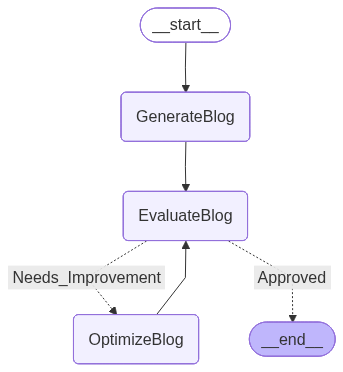

In [63]:
graph = StateGraph(CreateValidateBlog)

graph.add_node("GenerateBlog", generate_blog)
graph.add_node("EvaluateBlog",  evaluator_blog)
graph.add_node("OptimizeBlog", optimizer_blog)

graph.add_edge(START, "GenerateBlog")
graph.add_edge("GenerateBlog", "EvaluateBlog")
graph.add_conditional_edges("EvaluateBlog", check_conditions, {"Approved":END, "Needs_Improvement": "OptimizeBlog"})
graph.add_edge("OptimizeBlog", "EvaluateBlog")

workflow = graph.compile()
workflow

In [70]:
workflow.invoke({"topic": "Indian Railways", "iteration":1, "max_iteration": 5})

{'topic': 'Indian Railways',
 'generated_blog': '🚂 Indian Railways: A Lifeline of Connectivity! \n\nWith over 68,000 km of track, it’s the largest rail network in Asia, linking cities to remote regions. From bustling trains to scenic routes, it serves millions daily. Innovations like smart coaches and Wi-Fi are enhancing travel experiences! 🚆 #IndianRailways #TravelIndia',
 'evaluation': 'Approved',
 'feedback': 'The blog provides a concise overview of Indian Railways, highlighting its expansive network and modern innovations that enhance the travel experience. The grammar is correct, and the sentence structure is solid, making it easy to read. The use of emojis adds a lively touch, although the hashtag is a bit generic. Overall, the content is clear and engaging.',
 'iteration': 1,
 'max_iteration': 5}

In [69]:
workflow.invoke({"topic": "People in India", "iteration":1, "max_iteration": 5})

{'topic': 'People in India',
 'generated_blog': 'India is a vibrant tapestry of cultures, languages, and traditions. With over 1.4 billion people, it boasts a unique blend of modernity and heritage. From bustling cities to tranquil villages, the resilience and diversity of its people shine through. Every interaction reveals stories steeped in history and warmth!',
 'evaluation': 'Approved',
 'feedback': 'The blog presents a vivid and engaging description of India, showcasing its cultural richness and diversity. The grammar is correct, and the sentence structure is varied and fluid, making it enjoyable to read. There are no excessive repetitions of characters or words, which contributes to the clarity of the piece. Overall, it effectively communicates a sense of warmth and connection to the subject matter.',
 'iteration': 1,
 'max_iteration': 5}